  E0 (1).csv: 309 rijen (2025-08-15 → 2026-03-22)
  E0 (2).csv: 380 rijen (2024-08-16 → 2025-05-25)
  E0 (3).csv: 380 rijen (2023-08-11 → 2024-05-19)
  E0 (4).csv: 380 rijen (2022-08-05 → 2023-05-28)
  E0 (5).csv: 380 rijen (2021-08-13 → 2022-05-22)
  E0 (6).csv: 380 rijen (2020-09-12 → 2021-05-23)

Totaal odds: 2209 wedstrijden
Kalman:      4128 wedstrijden
B365 gevuld: 2209
PSH gevuld:  2110

Kalman kansen berekend voor 4128 wedstrijden
Gekoppeld: 2190 wedstrijden
Periode:   2020-09-12 → 2026-03-22

  BET365  (edge ≥ 5%)
  Wedstrijden beschikbaar: 2190
  Bets geplaatst:          996
  Netto resultaat:         €13.54
  ROI:                     +1.4%
  Win rate:                26.1%

  PINNACLE  (edge ≥ 5%)
  Wedstrijden beschikbaar: 2072
  Bets geplaatst:          970
  Netto resultaat:         €-23.98
  ROI:                     -2.5%
  Win rate:                25.3%


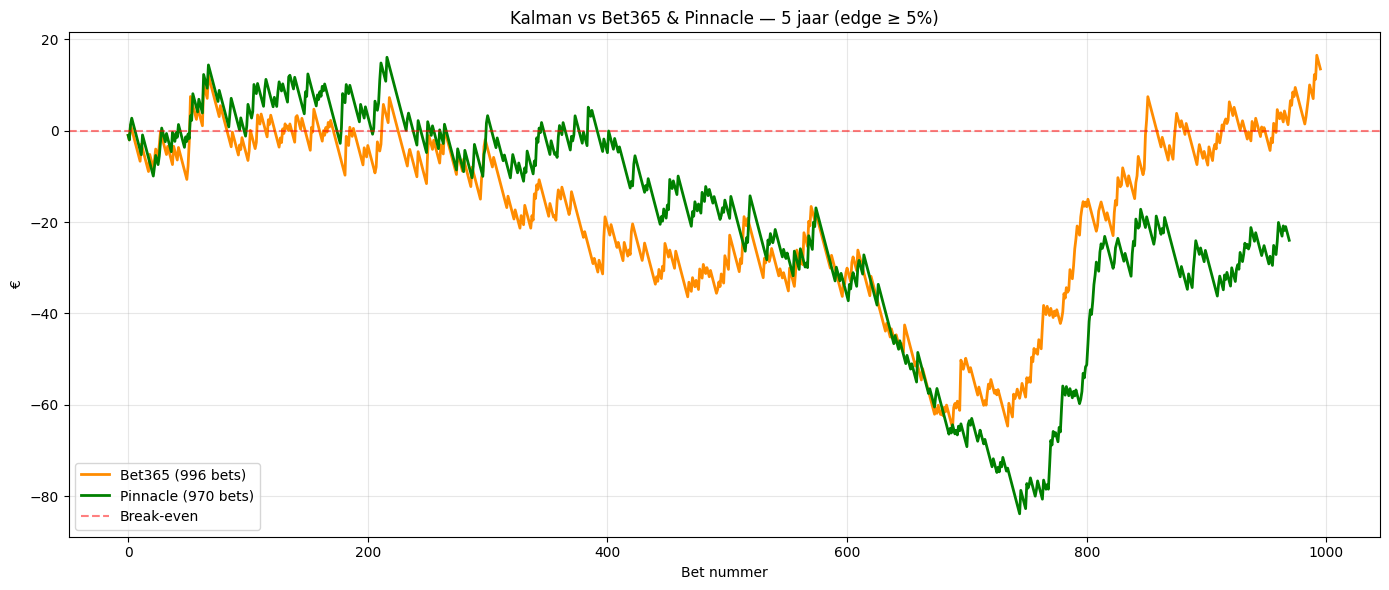


=== ROI BIJ VERSCHILLENDE DREMPELS ===
 Drempel | B365 bets  B365 ROI | Pinn bets  Pinn ROI
-------------------------------------------------------
    0.00 |      2190     -0.5% |      2072     +0.6%
    0.02 |      1812     +0.1% |      1706     -0.8%
    0.05 |       996     +1.4% |       970     -2.5%
    0.08 |       459     -2.5% |       441    -10.9%
    0.10 |       243    -11.1% |       232    -12.3%
    0.15 |        47    +21.4% |        46     +8.8%
    0.20 |         8    +42.5% |         6    +24.3%

=== ACCURACY ===
Kalman:   0.536
Bet365:   0.546


TypeError: '<' not supported between instances of 'float' and 'str'

In [12]:
"""
Kalman Betting Simulatie — Bet365 + Pinnacle (5 jaar)
======================================================
Input:
  - Kalman data/kalman_expected_goals.csv
  - odds raw/E0*.csv  (2020 t/m 2025)
"""

import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\semwi\FPL-Core-Insights\data"
os.chdir(BASE_DIR)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 1 — Data laden
# ══════════════════════════════════════════════════════════════════════════════
kalman = pd.read_csv(r"Kalman data\kalman_expected_goals.csv")
kalman['date'] = pd.to_datetime(kalman['date'])

ODDS_TEAM_MAP = {
    "Man United":    "Manchester United",
    "Man City":      "Manchester City",
    "Tottenham":     "Tottenham Hotspur",
    "Newcastle":     "Newcastle United",
    "Brighton":      "Brighton & Hove Albion",
    "West Ham":      "West Ham United",
    "Leicester":     "Leicester City",
    "Ipswich":       "Ipswich Town",
    "Luton":         "Luton Town",
    "Wolves":        "Wolverhampton Wanderers",
    "Wolverhampton": "Wolverhampton Wanderers",
    "Nott'm Forest": "Nottingham Forest",
    "Leeds":         "Leeds United",
    "West Brom":     "West Bromwich Albion",
}

KALMAN_TEAM_MAP = {
    "Wolverhampton":          "Wolverhampton Wanderers",
    "Wolverhampton Wanderers":"Wolverhampton Wanderers",
}

# Laad alle odds bestanden vanaf 2020
odds_dfs = []
for path in sorted(glob.glob(os.path.join(BASE_DIR, r"odds raw\E0*.csv"))):
    df = pd.read_csv(path, encoding='latin-1')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df[df['Date'] >= '2020-08-01']
    if len(df) > 0:
        odds_dfs.append(df)
        print(f"  {os.path.basename(path)}: {len(df)} rijen ({df['Date'].min().date()} → {df['Date'].max().date()})")

odds = pd.concat(odds_dfs, ignore_index=True)
odds['HomeTeam'] = odds['HomeTeam'].replace(ODDS_TEAM_MAP)
odds['AwayTeam'] = odds['AwayTeam'].replace(ODDS_TEAM_MAP)
odds['_date'] = odds['Date'].dt.date.astype(str)

print(f"\nTotaal odds: {len(odds)} wedstrijden")
print(f"Kalman:      {len(kalman)} wedstrijden")
print(f"B365 gevuld: {odds['B365H'].notna().sum()}")
print(f"PSH gevuld:  {odds['PSH'].notna().sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 2 — Poisson kansen via Dixon-Coles
# ══════════════════════════════════════════════════════════════════════════════
def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    SCALE_HOME = 1.679 / 1.595
    SCALE_AWAY = 1.438 / 1.327
    lambda_home = max(lambda_home * SCALE_HOME, 0.05)
    lambda_away = max(lambda_away * SCALE_AWAY, 0.05)
    prob_home = prob_draw = prob_away = 0.0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p
    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# ══════════════════════════════════════════════════════════════════════════════
# STAP 3 — Kalman kansen berekenen
# ══════════════════════════════════════════════════════════════════════════════
kalman_valid = kalman[kalman['kalman_xg_pred_home'].notna()].copy()
kalman_valid['home_team'] = kalman_valid['home_team'].replace(KALMAN_TEAM_MAP)
kalman_valid['away_team'] = kalman_valid['away_team'].replace(KALMAN_TEAM_MAP)

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(row['kalman_xg_pred_home'], row['kalman_xg_pred_away']),
    axis=1
)
kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]
kalman_valid['_date'] = kalman_valid['date'].dt.date.astype(str)
print(f"\nKalman kansen berekend voor {len(kalman_valid)} wedstrijden")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 4 — Mergen Kalman + Odds
# ══════════════════════════════════════════════════════════════════════════════
merged = kalman_valid.merge(
    odds[['_date', 'HomeTeam', 'AwayTeam',
          'FTHG', 'FTAG',
          'B365H', 'B365D', 'B365A',
          'PSH',   'PSD',   'PSA']],
    left_on=['_date', 'home_team', 'away_team'],
    right_on=['_date', 'HomeTeam', 'AwayTeam'],
    how='inner'
).drop(columns=['HomeTeam', 'AwayTeam', '_date'])

# Goals uit odds bestand (betrouwbaarder dan kalman voor hist. data)
merged['home_goals'] = merged['FTHG'].astype(float)
merged['away_goals'] = merged['FTAG'].astype(float)
merged = merged[merged['home_goals'].notna() & merged['away_goals'].notna()].copy()
merged['result'] = merged.apply(
    lambda r: 'H' if r['home_goals'] > r['away_goals'] else ('A' if r['home_goals'] < r['away_goals'] else 'D'),
    axis=1
)

# Odds → genormaliseerde kansen (marge eruit)
for bookie, cols in [('b365', ['B365H','B365D','B365A']), ('pinn', ['PSH','PSD','PSA'])]:
    h, d, a = cols
    merged[f'{bookie}_prob_home'] = 1 / merged[h]
    merged[f'{bookie}_prob_draw'] = 1 / merged[d]
    merged[f'{bookie}_prob_away'] = 1 / merged[a]
    total = merged[f'{bookie}_prob_home'] + merged[f'{bookie}_prob_draw'] + merged[f'{bookie}_prob_away']
    merged[f'{bookie}_prob_home'] /= total
    merged[f'{bookie}_prob_draw'] /= total
    merged[f'{bookie}_prob_away'] /= total

print(f"Gekoppeld: {len(merged)} wedstrijden")
print(f"Periode:   {merged['date'].min().date()} → {merged['date'].max().date()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 5 — Simulatie functie
# ══════════════════════════════════════════════════════════════════════════════
def simuleer(df, bookie_label, prob_h, prob_d, prob_a, odds_h, odds_d, odds_a, edge_threshold):
    sim = df[df[odds_h].notna()].copy()
    bet_results = []
    bankroll = 0.0
    bets = 0

    for _, row in sim.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row[prob_h],
            'D': row['kalman_prob_draw'] - row[prob_d],
            'A': row['kalman_prob_away'] - row[prob_a],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= edge_threshold:
            bets += 1
            bookie_odds = row[odds_h if best=='H' else odds_d if best=='D' else odds_a]
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            bankroll += profit
            bet_results.append({
                'match':      f"{row['home_team']} vs {row['away_team']}",
                'date':       str(row['date'].date()),
                'bet':        best,
                'result':     row['result'],
                'edge':       round(edges[best], 3),
                'odds':       round(bookie_odds, 2),
                'profit':     round(profit, 2),
                'cumulative': round(bankroll, 2),
                'won':        row['result'] == best,
            })

    results_df = pd.DataFrame(bet_results)
    roi = bankroll/bets*100 if bets > 0 else 0
    winrate = results_df['won'].mean()*100 if len(results_df) > 0 else 0

    print(f"\n{'='*55}")
    print(f"  {bookie_label}  (edge ≥ {edge_threshold*100:.0f}%)")
    print(f"{'='*55}")
    print(f"  Wedstrijden beschikbaar: {len(sim)}")
    print(f"  Bets geplaatst:          {bets}")
    print(f"  Netto resultaat:         €{bankroll:.2f}")
    print(f"  ROI:                     {roi:+.1f}%")
    print(f"  Win rate:                {winrate:.1f}%")

    return results_df

EDGE = 0.05

res_b365 = simuleer(merged, "BET365",
    'b365_prob_home', 'b365_prob_draw', 'b365_prob_away',
    'B365H', 'B365D', 'B365A', EDGE)

res_pinn = simuleer(merged, "PINNACLE",
    'pinn_prob_home', 'pinn_prob_draw', 'pinn_prob_away',
    'PSH', 'PSD', 'PSA', EDGE)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 6 — Visualisatie
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

if len(res_b365) > 0:
    ax.plot(range(len(res_b365)), res_b365['cumulative'], linewidth=2,
            color='darkorange', label=f'Bet365 ({len(res_b365)} bets)')
if len(res_pinn) > 0:
    ax.plot(range(len(res_pinn)), res_pinn['cumulative'], linewidth=2,
            color='green', label=f'Pinnacle ({len(res_pinn)} bets)')

ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax.set_title(f'Kalman vs Bet365 & Pinnacle — 5 jaar (edge ≥ {EDGE*100:.0f}%)')
ax.set_xlabel('Bet nummer')
ax.set_ylabel('€')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kalman_betting_5jaar.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# STAP 7 — ROI tabel bij verschillende drempels
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== ROI BIJ VERSCHILLENDE DREMPELS ===")
print(f"{'Drempel':>8} | {'B365 bets':>9} {'B365 ROI':>9} | {'Pinn bets':>9} {'Pinn ROI':>9}")
print("-" * 55)

for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    for bookie, ph, pd_, pa, oh, od, oa in [
        ('b365', 'b365_prob_home','b365_prob_draw','b365_prob_away','B365H','B365D','B365A'),
        ('pinn', 'pinn_prob_home','pinn_prob_draw','pinn_prob_away','PSH','PSD','PSA'),
    ]:
        winst = bets = 0
        for _, row in merged[merged[oh].notna()].iterrows():
            edges = {
                'H': row['kalman_prob_home'] - row[ph],
                'D': row['kalman_prob_draw'] - row[pd_],
                'A': row['kalman_prob_away'] - row[pa],
            }
            best = max(edges, key=edges.get)
            if edges[best] >= drempel:
                bets += 1
                bookie_odds = row[oh if best=='H' else od if best=='D' else oa]
                if pd.isna(bookie_odds) or bookie_odds <= 1:
                    continue
                winst += (bookie_odds - 1) if row['result'] == best else -1
        roi = winst/bets*100 if bets > 0 else 0
        if bookie == 'b365':
            b_b, r_b = bets, roi
        else:
            b_n, r_n = bets, roi

    print(f"{drempel:>8.2f} | {b_b:>9d} {r_b:>+8.1f}% | {b_n:>9d} {r_n:>+8.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 8 — Accuracy & Brier score
# ══════════════════════════════════════════════════════════════════════════════
merged['kalman_pred'] = merged[['kalman_prob_home','kalman_prob_draw','kalman_prob_away']].idxmax(axis=1)
merged['kalman_pred'] = merged['kalman_pred'].map({'kalman_prob_home':'H','kalman_prob_draw':'D','kalman_prob_away':'A'})
merged['b365_pred']   = merged[['b365_prob_home','b365_prob_draw','b365_prob_away']].idxmax(axis=1)
merged['b365_pred']   = merged['b365_pred'].map({'b365_prob_home':'H','b365_prob_draw':'D','b365_prob_away':'A'})
merged['pinn_pred']   = merged[['pinn_prob_home','pinn_prob_draw','pinn_prob_away']].idxmax(axis=1)
merged['pinn_pred']   = merged['pinn_pred'].map({'pinn_prob_home':'H','pinn_prob_draw':'D','pinn_prob_away':'A'})

print("\n=== ACCURACY ===")
print(f"Kalman:   {accuracy_score(merged['result'], merged['kalman_pred']):.3f}")
print(f"Bet365:   {accuracy_score(merged['result'], merged['b365_pred']):.3f}")
print(f"Pinnacle: {accuracy_score(merged['result'], merged['pinn_pred']):.3f}")

print("\n=== BRIER SCORE (lager = beter) ===")
print(f"{'':10s} {'Kalman':>8} {'Bet365':>8} {'Pinnacle':>8}")
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (merged['result'] == outcome).astype(int)
    suf = 'home' if outcome=='H' else 'draw' if outcome=='D' else 'away'
    bk = brier_score_loss(actual_bin, merged[f'kalman_prob_{suf}'])
    bb = brier_score_loss(actual_bin, merged[f'b365_prob_{suf}'])
    bp = brier_score_loss(actual_bin, merged[f'pinn_prob_{suf}'])
    print(f"{label:10s} {bk:>8.3f} {bb:>8.3f} {bp:>8.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 9 — Random baseline
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== RANDOM BASELINE (1000x, Bet365 odds) ===")
random.seed(42)
random_rois = []
sim_rand = merged[merged['B365H'].notna()].copy()
for _ in range(1000):
    winst = 0
    for _, row in sim_rand.iterrows():
        bet = random.choice(['H','D','A'])
        bookie_odds = row['B365H' if bet=='H' else 'B365D' if bet=='D' else 'B365A']
        winst += (bookie_odds - 1) if row['result'] == bet else -1
    random_rois.append(winst/len(sim_rand)*100)

p5  = np.percentile(random_rois, 2.5)
p95 = np.percentile(random_rois, 97.5)
model_roi = (res_b365['profit'].sum()/len(res_b365)*100) if len(res_b365) > 0 else 0

print(f"Gemiddelde random ROI: {np.mean(random_rois):+.1f}%")
print(f"95% interval:         [{p5:+.1f}%, {p95:+.1f}%]")
print(f"Kalman B365 ROI:      {model_roi:+.1f}%")
if p5 < model_roi < p95:
    print("⚠️  Niet statistisch significant")
else:
    print("✅ Statistisch significant op 95% niveau")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEAKAGE CHECK — Kalman xG versie
# ══════════════════════════════════════════════════════════════════════════════
print("=== LEAKAGE CHECK ===")

# 1. Correlatie tussen Kalman xG voorspelling en werkelijke goals
corr_h = merged['kalman_xg_pred_home'].corr(merged['home_goals'])
corr_a = merged['kalman_xg_pred_away'].corr(merged['away_goals'])
print(f"Correlatie pred home xG vs werkelijke goals: {corr_h:.3f}")
print(f"Correlatie pred away xG vs werkelijke goals: {corr_a:.3f}")
print("(~0.2-0.4 = normaal, >0.6 = verdacht)")

# 2. Eerste wedstrijd per team moet neutraal zijn (alpha=0, gamma=0)
# → voorspelling = alleen DELTA=0.15
print(f"\nVoorspelling eerste wedstrijd (verwacht ≈ DELTA=0.15 thuis, 0.0 uit):")
first_matches = merged.sort_values('date').groupby('home_team').first()
print(f"  Gemiddeld kalman_xg_pred_home eerste wedstrijd: {first_matches['kalman_xg_pred_home'].mean():.3f}")
print(f"  Gemiddeld kalman_xg_pred_away eerste wedstrijd: {first_matches['kalman_xg_pred_away'].mean():.3f}")

# 3. Correlatie pred met huidige vs vorige wedstrijd goals
merged_sorted = merged.sort_values(['home_team', 'date'])
merged_sorted['prev_home_goals'] = merged_sorted.groupby('home_team')['home_goals'].shift(1)
corr_prev = merged_sorted['kalman_xg_pred_home'].corr(merged_sorted['prev_home_goals'])
corr_curr = merged_sorted['kalman_xg_pred_home'].corr(merged_sorted['home_goals'])
print(f"\nCorrelatie pred met HUIDIGE wedstrijd goals:  {corr_curr:.3f}")
print(f"Correlatie pred met VORIGE wedstrijd goals:   {corr_prev:.3f}")
print("(als curr ≈ prev = geen leakage, model leert geleidelijk)")
print("(als curr >> prev = mogelijk leakage)")

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# KWARTAAL ANALYSE — per seizoen + overall
# ══════════════════════════════════════════════════════════════════════════════
print("=== PRESTATIE PER KWARTAAL VAN HET SEIZOEN ===")

merged_sorted = merged.sort_values(['season', 'date']).copy()
merged_sorted['match_nr'] = merged_sorted.groupby('season').cumcount() + 1
merged_sorted['kwartaal'] = pd.cut(
    merged_sorted['match_nr'],
    bins=[0, 95, 190, 285, 999],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

EDGE = 0.05
kwartalen = ['Q1', 'Q2', 'Q3', 'Q4']

def kwartaal_stats(subset, oh, od, oa, ph, pd_, pa):
    winst = bets = wins = 0
    for _, row in subset.iterrows():
        if pd.isna(row[oh]):
            continue
        edges = {
            'H': row['kalman_prob_home'] - row[ph],
            'D': row['kalman_prob_draw'] - row[pd_],
            'A': row['kalman_prob_away'] - row[pa],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= EDGE:
            bets += 1
            bookie_odds = row[oh if best=='H' else od if best=='D' else oa]
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            winst += profit
            wins += 1 if row['result'] == best else 0
    roi     = winst/bets*100 if bets > 0 else 0
    winrate = wins/bets*100  if bets > 0 else 0
    return bets, winst, roi, winrate

for bookie, ph, pd_, pa, oh, od, oa in [
    ('BET365',   'b365_prob_home','b365_prob_draw','b365_prob_away','B365H','B365D','B365A'),
    ('PINNACLE', 'pinn_prob_home','pinn_prob_draw','pinn_prob_away','PSH',  'PSD',  'PSA'),
]:
    print(f"\n{'='*75}")
    print(f"  {bookie}")
    print(f"{'='*75}")
    print(f"  {'Seizoen':<12} {'Q1 bets':>7} {'Q1 ROI':>7} {'Q2 bets':>7} {'Q2 ROI':>7} {'Q3 bets':>7} {'Q3 ROI':>7} {'Q4 bets':>7} {'Q4 ROI':>7}")
    print(f"  {'-'*75}")

    # Per seizoen
    overall = {q: {'bets':0,'winst':0,'wins':0} for q in kwartalen}

    for seizoen in sorted(merged_sorted['season'].unique()):
        seizoen_data = merged_sorted[merged_sorted['season'] == seizoen]
        row_parts = f"  {str(seizoen):<12}"

        for q in kwartalen:
            subset = seizoen_data[seizoen_data['kwartaal'] == q]
            bets, winst, roi, winrate = kwartaal_stats(subset, oh, od, oa, ph, pd_, pa)
            row_parts += f" {bets:>7} {roi:>+6.1f}%"

            # Verzamel voor overall
            overall[q]['bets']  += bets
            overall[q]['winst'] += winst
            overall[q]['wins']  += int(bets * winrate / 100) if bets > 0 else 0

        print(row_parts)

    # Overall totaal
    print(f"  {'-'*75}")
    row_overall = f"  {'TOTAAL':<12}"
    for q in kwartalen:
        b = overall[q]['bets']
        w = overall[q]['winst']
        roi = w/b*100 if b > 0 else 0
        row_overall += f" {b:>7} {roi:>+6.1f}%"
    print(row_overall)

=== PRESTATIE PER KWARTAAL VAN HET SEIZOEN ===

  BET365
  Seizoen      Q1 bets  Q1 ROI Q2 bets  Q2 ROI Q3 bets  Q3 ROI Q4 bets  Q4 ROI
  ---------------------------------------------------------------------------
  2020/2021         43   -8.5%      44   +0.3%      39   +2.4%      40   +8.3%
  2021/2022         47   +2.8%      54   -6.7%      34   -6.9%      26  -63.1%
  2022/2023         42   +4.7%      38  -13.7%      33  -27.4%      45   +3.6%
  2023/2024         48   +4.2%      43  +22.9%      52  -38.1%      47  -46.8%
  2024/2025         53   +6.0%      43  +43.7%      42  +55.5%      42  +47.8%
  2025/2026         45  -22.2%      42  +19.7%      41   -3.0%      13  +92.7%
  ---------------------------------------------------------------------------
  TOTAAL           278   -1.8%     264  +10.7%     241   -3.4%     213   -0.6%

  PINNACLE
  Seizoen      Q1 bets  Q1 ROI Q2 bets  Q2 ROI Q3 bets  Q3 ROI Q4 bets  Q4 ROI
  --------------------------------------------------------------